# Calculate mAP scores comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from copairs import map  # noqa: A004
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_abline,
    geom_bar,
    geom_hline,
    geom_point,
    ggplot,
    labs,
    scale_color_gradientn,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option

## Helper functions

In [2]:
# Perform mean average precision calculation
def get_mean_average_precision(  # noqa: PLR0913
    activity_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mean average precision for activity data.

    Args:
        activity_df (pd.DataFrame): Activity data.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        seed (int, optional): Random seed for reproducibility. Defaults to 0.

    Returns:
        pd.DataFrame: Mean average precision results.
    """
    metadata = activity_df.filter(regex="^Metadata")
    profiles = activity_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    activity_ap = activity_ap.query("Metadata_broad_sample != 'DMSO'")

    activity_map = map.mean_average_precision(
        activity_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)
    return activity_map


# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)

## Load in the data for pre and post QC

In [3]:
# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

# Output path for merged profiles
output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

# Load cell painting profiles (pre-QC)
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)
pre_qc_df = pre_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])

# Load cell painting profiles (post-QC)
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

In [4]:
# Compute percentage of failed QC single-cell across all plates in post_qc_df
total_failed = post_qc_df["Metadata_sc_count_failed_qc"].sum()
total_cells = post_qc_df["Metadata_sc_count"].sum()
failed_qc_percentage = (total_failed / total_cells) * 100
print(
    f"Percentage of failed QC single-cell across all plates: "
    f"{failed_qc_percentage:.2f}%"
)

Percentage of failed QC single-cell across all plates: 29.03%


In [5]:
# Calculate proportion of failed cells for each well
post_qc_df["failed_proportion"] = post_qc_df["Metadata_sc_count_failed_qc"] / (
    post_qc_df["Metadata_sc_count_failed_qc"]
    + post_qc_df["Metadata_sc_count_passed_qc"]
)

# Compare failed proportions between compounds and DMSO
compound_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] != "DMSO", "failed_proportion"
]
dmso_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] == "DMSO", "failed_proportion"
]

# Print mean failed proportions
print(f"Mean failed proportion (compounds): {compound_failed.mean():.4f}")
print(f"Mean failed proportion (DMSO): {dmso_failed.mean():.4f}")

Mean failed proportion (compounds): 0.3019
Mean failed proportion (DMSO): 0.2970


## Assign reference index

In [6]:
reference_col = "Metadata_reference_index"

pre_qc_df_activity = assign_reference_index(
    pre_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles
    reference_col=reference_col,
    default_value=-1,
)

post_qc_df_activity = assign_reference_index(
    post_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles
    reference_col=reference_col,
    default_value=-1,
)

## Set positive and negative pairs for compounds

In [7]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]

## Calculate mAP scores per treatment compared to controls for both pre- and post-QC

### Pre-QC dataframe

In [8]:
preqc_map_file = f"{output_dir}/final_map_scores_preQC.parquet"
if os.path.exists(preqc_map_file):
    final_map_preQC = pd.read_parquet(preqc_map_file)
    print("Loaded preQC mAP results from file.")
else:
    list_of_dfs_map_preQC = []
    for treatment in pre_qc_df_activity["Metadata_broad_sample"].unique():
        if treatment == "DMSO":
            continue
        treatment_plates = pre_qc_df_activity.loc[
            pre_qc_df_activity["Metadata_broad_sample"] == treatment, "Metadata_Plate"
        ].unique()
        treatment_df = pre_qc_df_activity[
            (
                (pre_qc_df_activity["Metadata_broad_sample"] == treatment)
                | (pre_qc_df_activity["Metadata_broad_sample"] == "DMSO")
            )
            & (pre_qc_df_activity["Metadata_Plate"].isin(treatment_plates))
        ]
        # Check if there are at least two replicates for positive pairing
        n_replicates = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ].shape[0]
        unique_pos_diffby = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ][pos_diffby].drop_duplicates()
        MIN_REPLICATES = 2  # Minimum number of replicates required
        if n_replicates < MIN_REPLICATES or unique_pos_diffby.shape[0] < MIN_REPLICATES:
            print(
                f"Skipping treatment {treatment}: not enough replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue
        # Calculate average proportion of failed single cells per dose
        failed_cells = (
            treatment_df[treatment_df["Metadata_broad_sample"] == treatment]
            .assign(
                Metadata_failed_prop=lambda x: (
                    x["Metadata_sc_count_failed_qc"] / x["Metadata_sc_count"]
                )
            )
            .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
            .mean()
        )
        # Perform mAP calculation per treatment (use defaults)
        treatment_map = get_mean_average_precision(
            treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
        )
        # Map average failed cells to treatment_map
        treatment_map["Metadata_avg_prop_failed_single_cells"] = treatment_map[
            "Metadata_dose_recode"
        ].map(failed_cells)
        list_of_dfs_map_preQC.append(treatment_map)

    # Concatenate all treatment mAP results
    final_map_preQC = pd.concat(list_of_dfs_map_preQC, ignore_index=True)
    final_map_preQC["QC_status"] = "pre-QC"
    # Save final mAP results to file
    final_map_preQC.to_parquet(preqc_map_file, index=False)

Loaded preQC mAP results from file.


### Post-QC dataframe

In [9]:
postqc_map_file = f"{output_dir}/final_map_scores_postQC.parquet"
if os.path.exists(postqc_map_file):
    final_map_postQC = pd.read_parquet(postqc_map_file)
    print("Loaded postQC mAP results from file.")
else:
    list_of_dfs_map_postQC = []
    for treatment in post_qc_df_activity["Metadata_broad_sample"].unique():
        if treatment == "DMSO":
            continue
        treatment_plates = post_qc_df_activity.loc[
            post_qc_df_activity["Metadata_broad_sample"] == treatment, "Metadata_Plate"
        ].unique()
        treatment_df = post_qc_df_activity[
            (
                (post_qc_df_activity["Metadata_broad_sample"] == treatment)
                | (post_qc_df_activity["Metadata_broad_sample"] == "DMSO")
            )
            & (post_qc_df_activity["Metadata_Plate"].isin(treatment_plates))
        ]
        # Check if there are at least two replicates for positive pairing
        n_replicates = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ].shape[0]
        unique_pos_diffby = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ][pos_diffby].drop_duplicates()
        if n_replicates < MIN_REPLICATES or unique_pos_diffby.shape[0] < MIN_REPLICATES:
            print(
                f"Skipping treatment {treatment}: not enough replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue
        # Calculate average proportion of failed single cells per dose
        failed_cells = (
            treatment_df[treatment_df["Metadata_broad_sample"] == treatment]
            .assign(
                Metadata_failed_prop=lambda x: (
                    x["Metadata_sc_count_failed_qc"] / x["Metadata_sc_count"]
                )
            )
            .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
            .mean()
        )
        # Perform mAP calculation per treatment (use defaults)
        treatment_map = get_mean_average_precision(
            treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
        )
        # Map average failed cells to treatment_map
        treatment_map["Metadata_avg_prop_failed_single_cells"] = treatment_map[
            "Metadata_dose_recode"
        ].map(failed_cells)
        list_of_dfs_map_postQC.append(treatment_map)

    # Concatenate all treatment mAP results
    final_map_postQC = pd.concat(list_of_dfs_map_postQC, ignore_index=True)
    final_map_postQC["QC_status"] = "post-QC"
    # Save final mAP results to file
    final_map_postQC.to_parquet(postqc_map_file, index=False)

Loaded postQC mAP results from file.


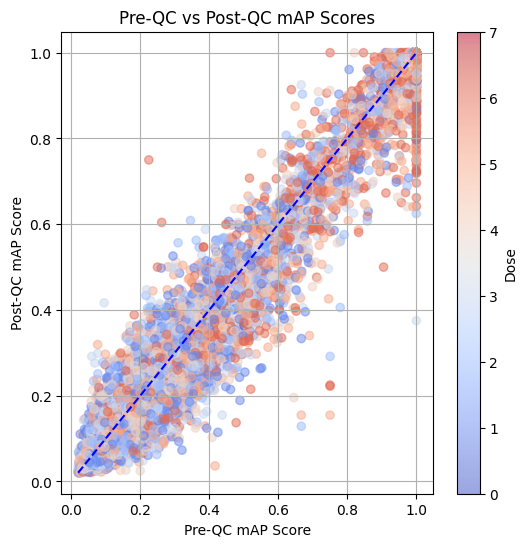

In [10]:
# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    final_map_preQC,
    final_map_postQC,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    merged_map["mean_average_precision_preQC"],
    merged_map["mean_average_precision_postQC"],
    c=merged_map["Metadata_dose_recode"],
    cmap="viridis",
    alpha=0.5,
)
plt.xlabel("Pre-QC mAP Score")
plt.ylabel("Post-QC mAP Score")
plt.title("Pre-QC vs Post-QC mAP Scores")
plt.grid(True)

# Add y = x reference line
lims = [
    min(
        merged_map["mean_average_precision_preQC"].min(),
        merged_map["mean_average_precision_postQC"].min(),
    ),
    max(
        merged_map["mean_average_precision_preQC"].max(),
        merged_map["mean_average_precision_postQC"].max(),
    ),
]
plt.plot(lims, lims, "b--", label="y = x")

cbar = plt.colorbar(scatter)
cbar.set_label("Dose")
scatter.set_cmap("coolwarm")

plt.show()

In [ ]:
# Compute change per row
merged_map["mAP_change"] = (
    merged_map["mean_average_precision_postQC"]
    - merged_map["mean_average_precision_preQC"]
)

# Filter rows where the preQC was low and the change was large
improved_rows = merged_map.query(
    "mean_average_precision_preQC <= 0.5 and mAP_change >= 0.2"
)

# Count unique compounds
num_improved = improved_rows["Metadata_broad_sample"].nunique()

# Compute percentage of all rows (compounds and doses) that improved
percent_improved = len(improved_rows) / len(merged_map) * 100

print(f"{num_improved} compounds with preQC ≤ 0.5 and an increase ≥ 0.2.")
print(f"These rows represent {percent_improved:.1f}% of all compounds/doses.")

20 compounds with preQC ≤ 0.5 and an increase ≥ 0.2.
These rows represent 0.2% of all compounds/doses.


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 14 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/mAP_preQC_vs_postQC_by_dose.png


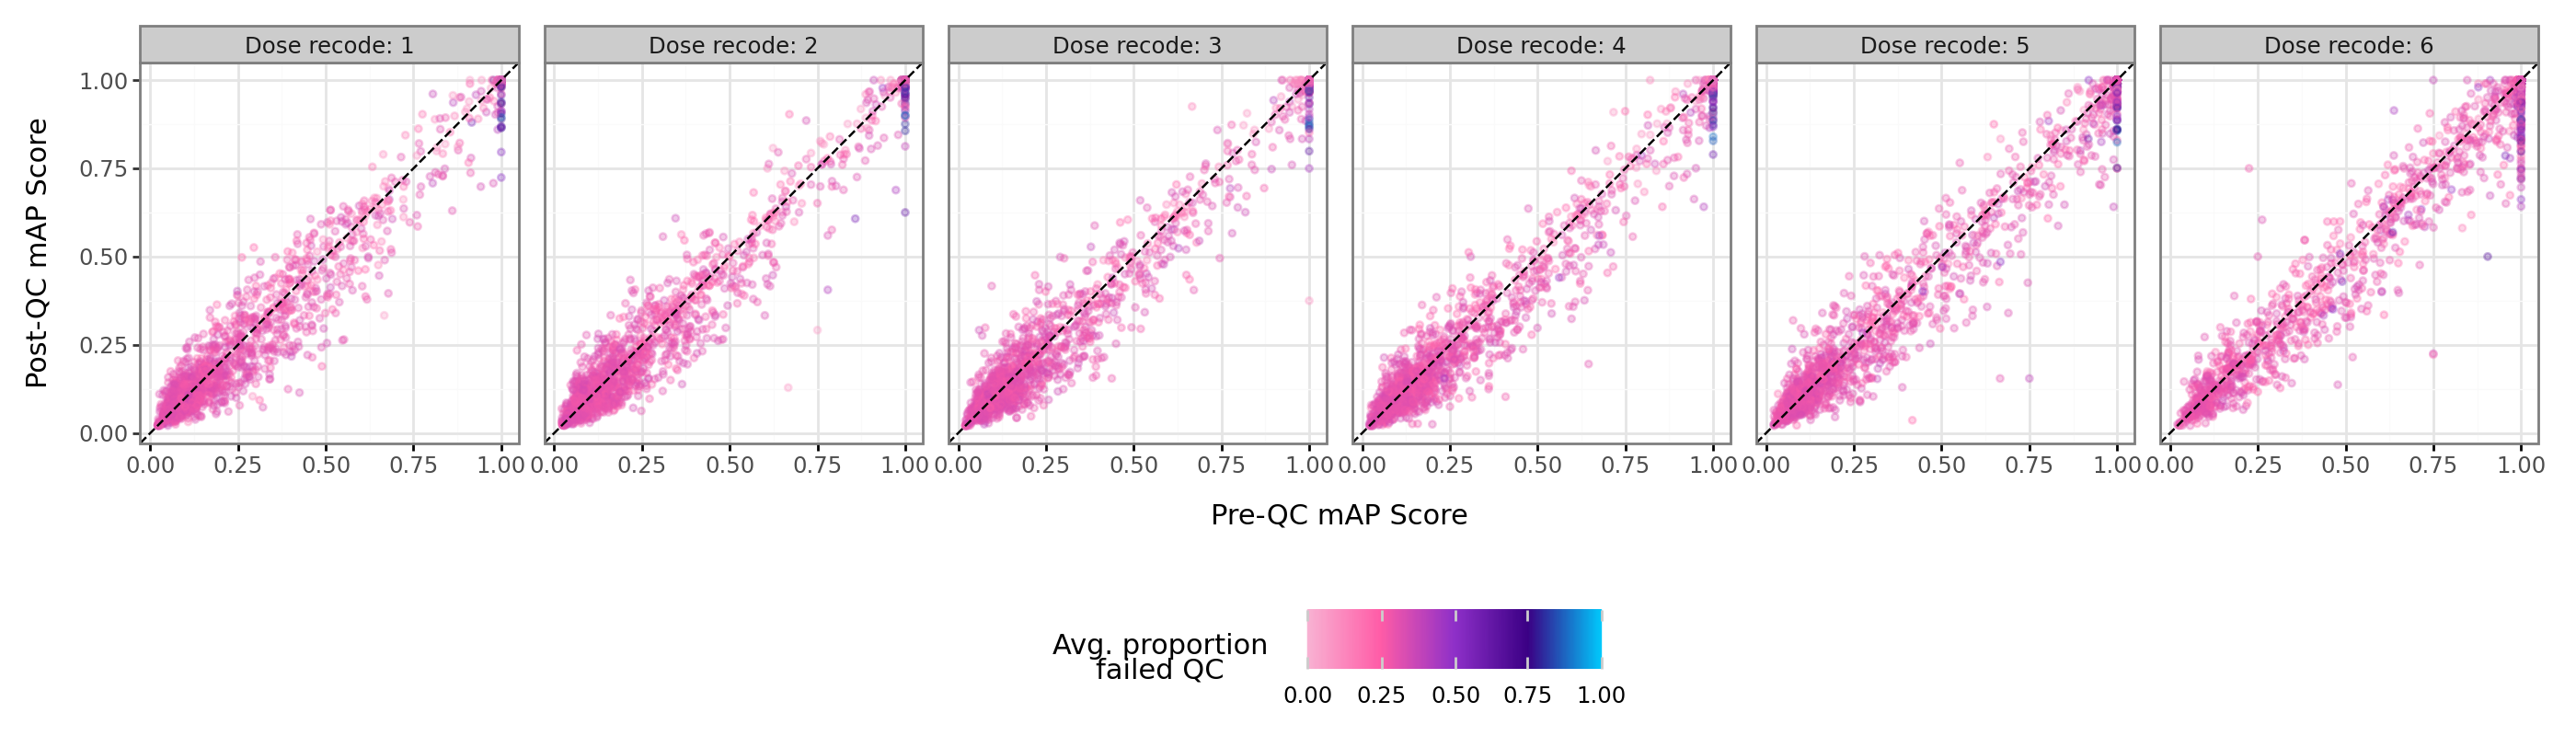

In [12]:
# Merge (as before)
merged_map = pd.merge(
    final_map_preQC,
    final_map_postQC,
    on=[
        "Metadata_broad_sample",
        "Metadata_dose_recode",
        "Metadata_avg_prop_failed_single_cells",
    ],
    suffixes=("_preQC", "_postQC"),
)
# Drop rows with dose recode 0 and 7 due to low sample size
merged_map = merged_map[~merged_map["Metadata_dose_recode"].isin([0, 7])]

# Set the figure size
height = 4
width = 14
set_option("figure_size", (width, height))

# Define the custom coSMic QC palette (lighter pink to purple to cyan)
cosmicqc_palette = [
    "#f8b3d3",  # Light pink
    "#ff5ca7",  # Vibrant pink
    "#8f30c9",  # Medium purple
    "#3b0085",  # Deep purple
    "#00cafd",  # Cyan accent
]

# Make the plotnine plot
p = (
    ggplot(
        merged_map,
        aes(
            x="mean_average_precision_preQC",
            y="mean_average_precision_postQC",
            color="Metadata_avg_prop_failed_single_cells",
        ),
    )
    + geom_point(alpha=0.3, size=1.0)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="black", size=0.5)
    + facet_wrap(
        "~Metadata_dose_recode", nrow=1, labeller=lambda x: f"Dose recode: {x}"
    )
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Pre-QC mAP Score",
        y="Post-QC mAP Score",
    )
    + theme_bw()
    + theme(
        legend_position="bottom",
    )
)

# Save as PNG
p.save("figures/mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    # rasterize scatter points only
    for coll in ax.collections:
        coll.set_rasterized(True)
    # keep lines and legend as vectors

# Save as SVG
fig.savefig("figures/mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

# To show the plot:
p.show()

In [13]:
# Get proportion of points above and below y=x line
proportion_df = proportion_above_below_y_eq_x(merged_map)
proportion_df

,Metadata_dose_recode,proportion_above,proportion_below,proportion_equal,n_points
0,1,0.422508,0.529904,0.047588,1555
1,2,0.416988,0.520592,0.062420,1554
2,3,0.408360,0.495177,0.096463,1555
3,4,0.346624,0.533119,0.120257,1555
4,5,0.344093,0.535184,0.120723,1549
5,6,0.262306,0.506477,0.231218,1544


/tmp/ipykernel_79939/3177098417.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_79939/3177098417.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 14 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/pl

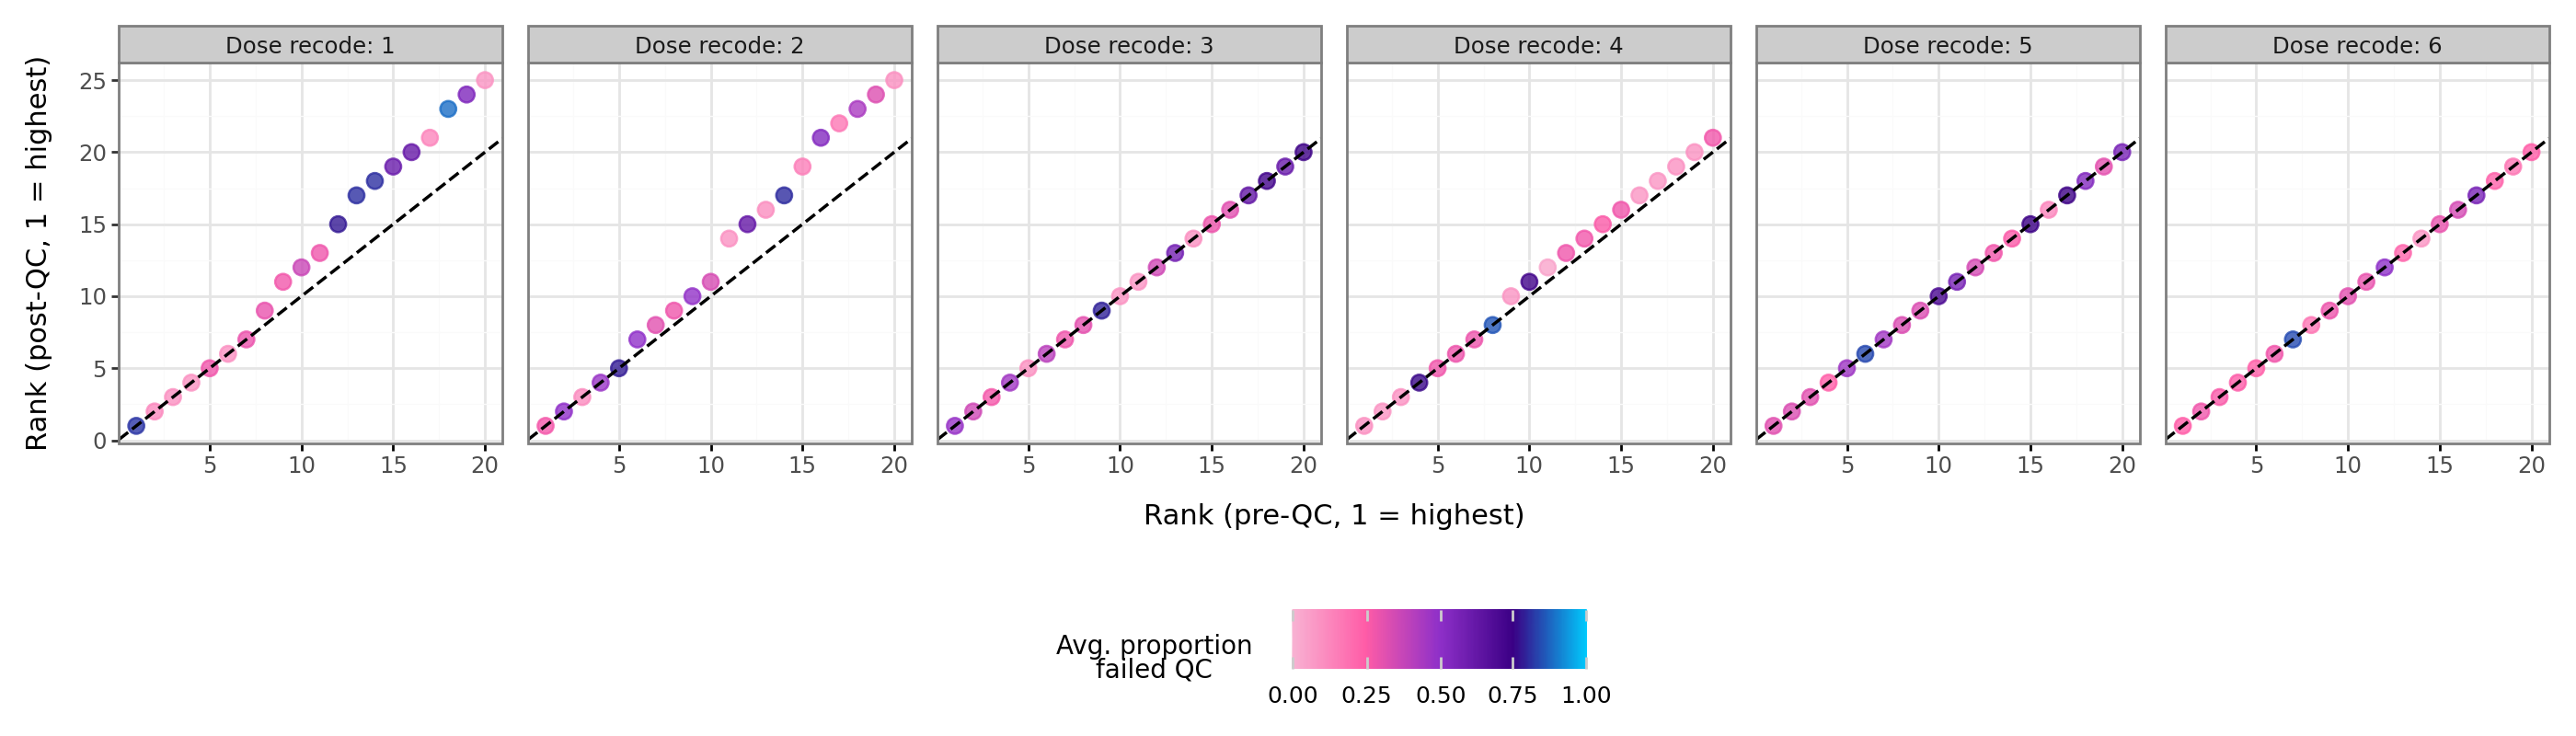

In [14]:
# Rank independently within each dose based on post-QC mAP
merged_map_sorted = merged_map.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.sort_values("mean_average_precision_postQC", ascending=False).assign(
        postQC_rank=lambda d: np.arange(1, len(d) + 1)
    )
)

# Rank independently within each dose  each dose based on pre-QC mAP
merged_map_sorted["preQC_rank"] = merged_map_sorted.groupby("Metadata_dose_recode")[
    "mean_average_precision_preQC"
].rank(ascending=False, method="first")

# Keep top 20 compounds per dose based on preQC ranking
merged_map_top = (
    merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False)
    .apply(lambda df: df.nsmallest(20, "preQC_rank"))
    .copy()
)

# Use the custom palette
p = (
    ggplot(
        merged_map_top,
        aes(
            x="preQC_rank",
            y="postQC_rank",
            color="Metadata_avg_prop_failed_single_cells",
        ),
    )
    + geom_point(size=3, alpha=0.8)
    + geom_abline(intercept=0, slope=1, linetype="--", color="black", size=0.7)
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Rank (pre-QC, 1 = highest)",
        y="Rank (post-QC, 1 = highest)",
        color="Avg prop failed cells",
    )
    + facet_wrap(
        "~Metadata_dose_recode",
        nrow=1,
        labeller=lambda x: f"Dose recode: {x}",
    )
    + theme_bw()
    + theme(
        figure_size=(14, 4),
        legend_position="bottom",
        legend_title=element_text(size=10),
        legend_text=element_text(size=9),
    )
)

# Save plots
p.save("figures/rank_mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    for coll in ax.collections:
        coll.set_rasterized(True)

fig.savefig("figures/rank_mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

p.show()

In [ ]:
# Print for dose recode 1 the sample, and ranks pre and post QC
merged_map_sorted.loc[
    merged_map_sorted["Metadata_dose_recode"] == 4,  # noqa: PLR2004
    [
        "Metadata_broad_sample",
        "preQC_rank",
        "postQC_rank",
    ],
].sort_values("postQC_rank").head(10)

,Metadata_broad_sample,preQC_rank,postQC_rank
9169,BRD-K97963946-001-01-3,1.0,1
171,BRD-A07704283-001-01-3,2.0,2
165,BRD-A07563059-035-01-3,3.0,3
135,BRD-A05821830-341-01-5,4.0,4
2629,BRD-K08248804-001-01-8,5.0,5
2659,BRD-K08799216-001-05-3,6.0,6
2689,BRD-K09078998-001-01-4,7.0,7
2503,BRD-K06858286-001-01-3,8.0,8
2557,BRD-K07310275-001-02-5,273.0,9
2587,BRD-K07798980-001-01-9,9.0,10


/tmp/ipykernel_79939/3350202403.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_79939/3350202403.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plo

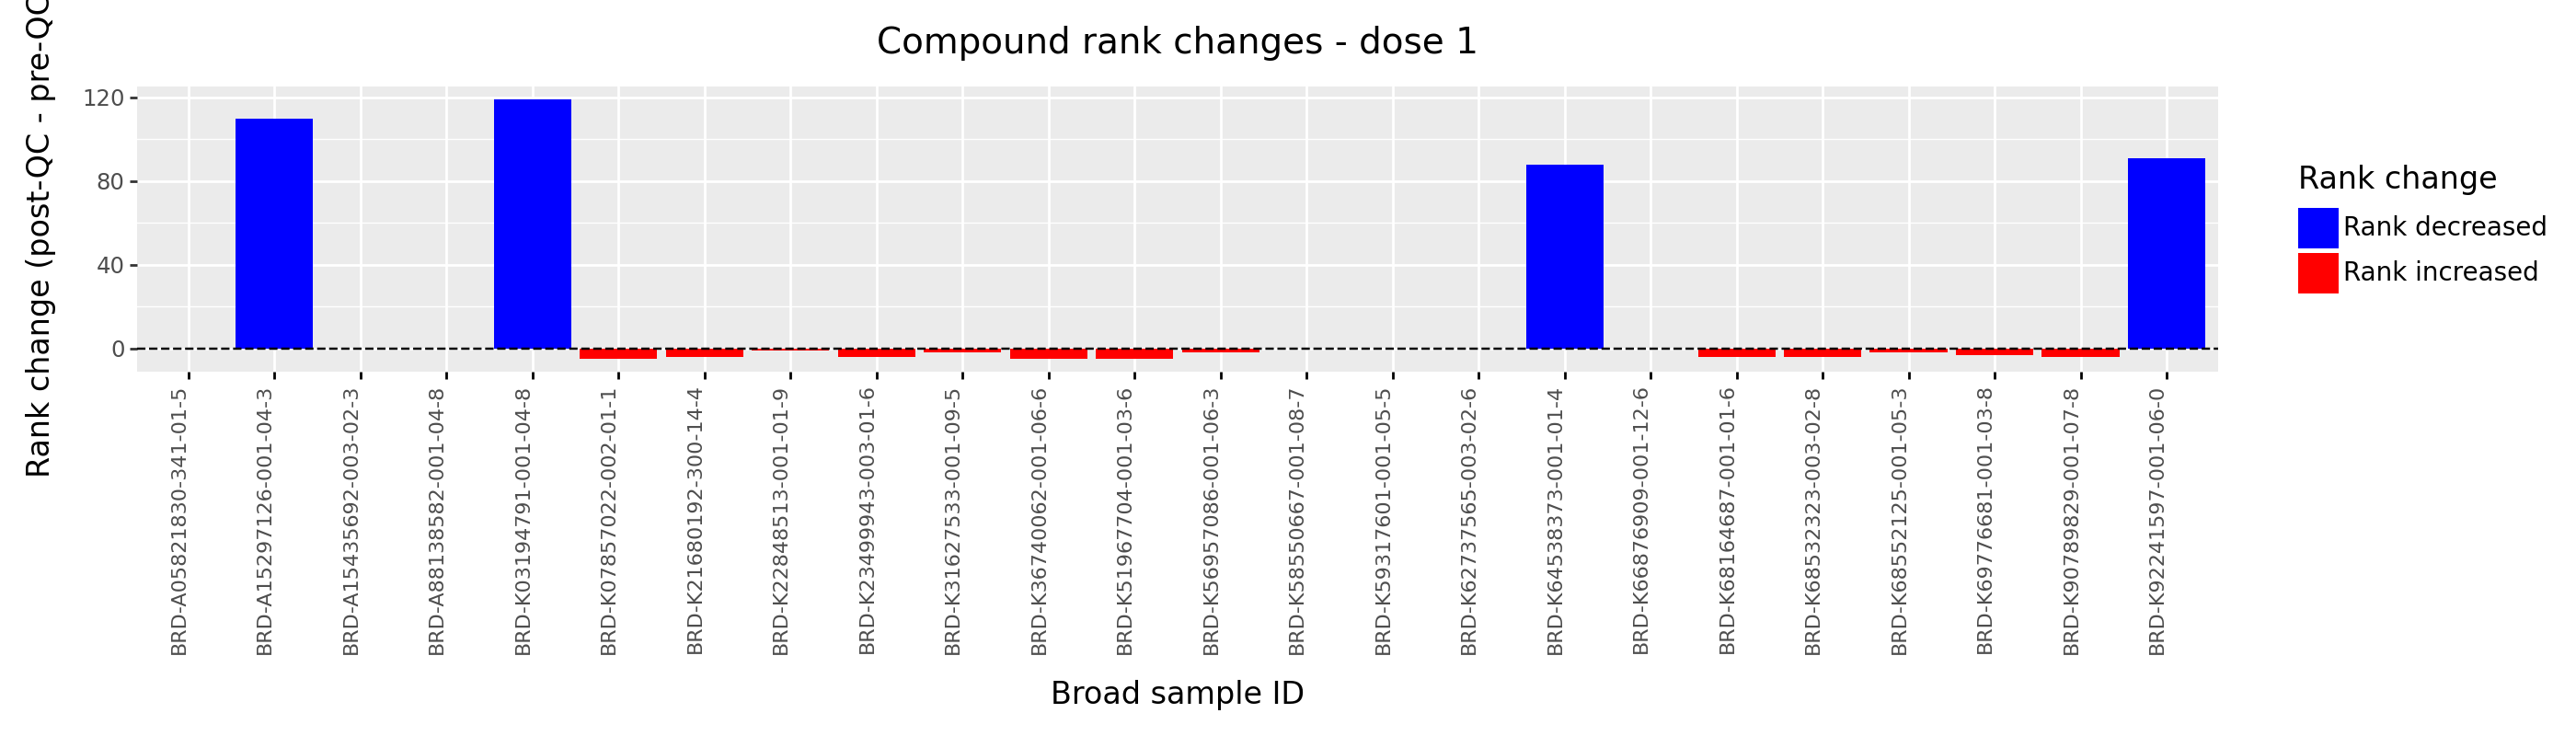

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/rank_change_dose_2_bar_plot.png


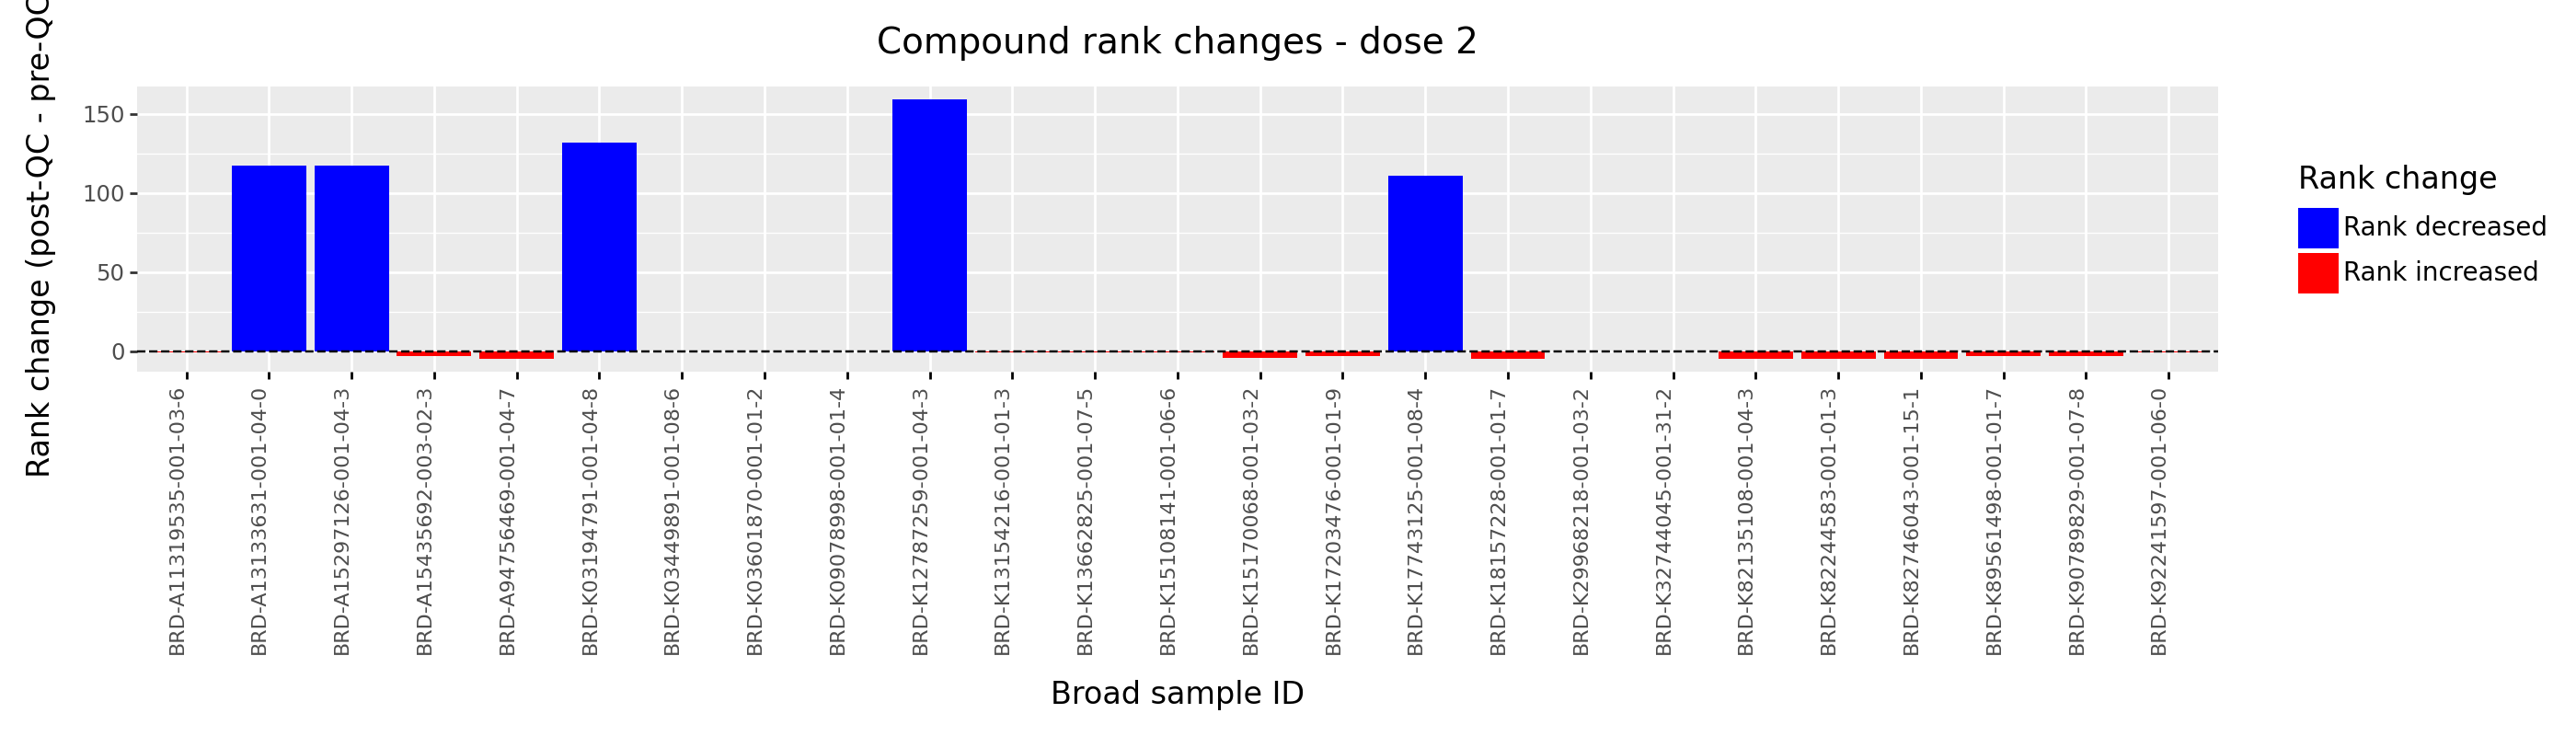

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/rank_change_dose_4_bar_plot.png


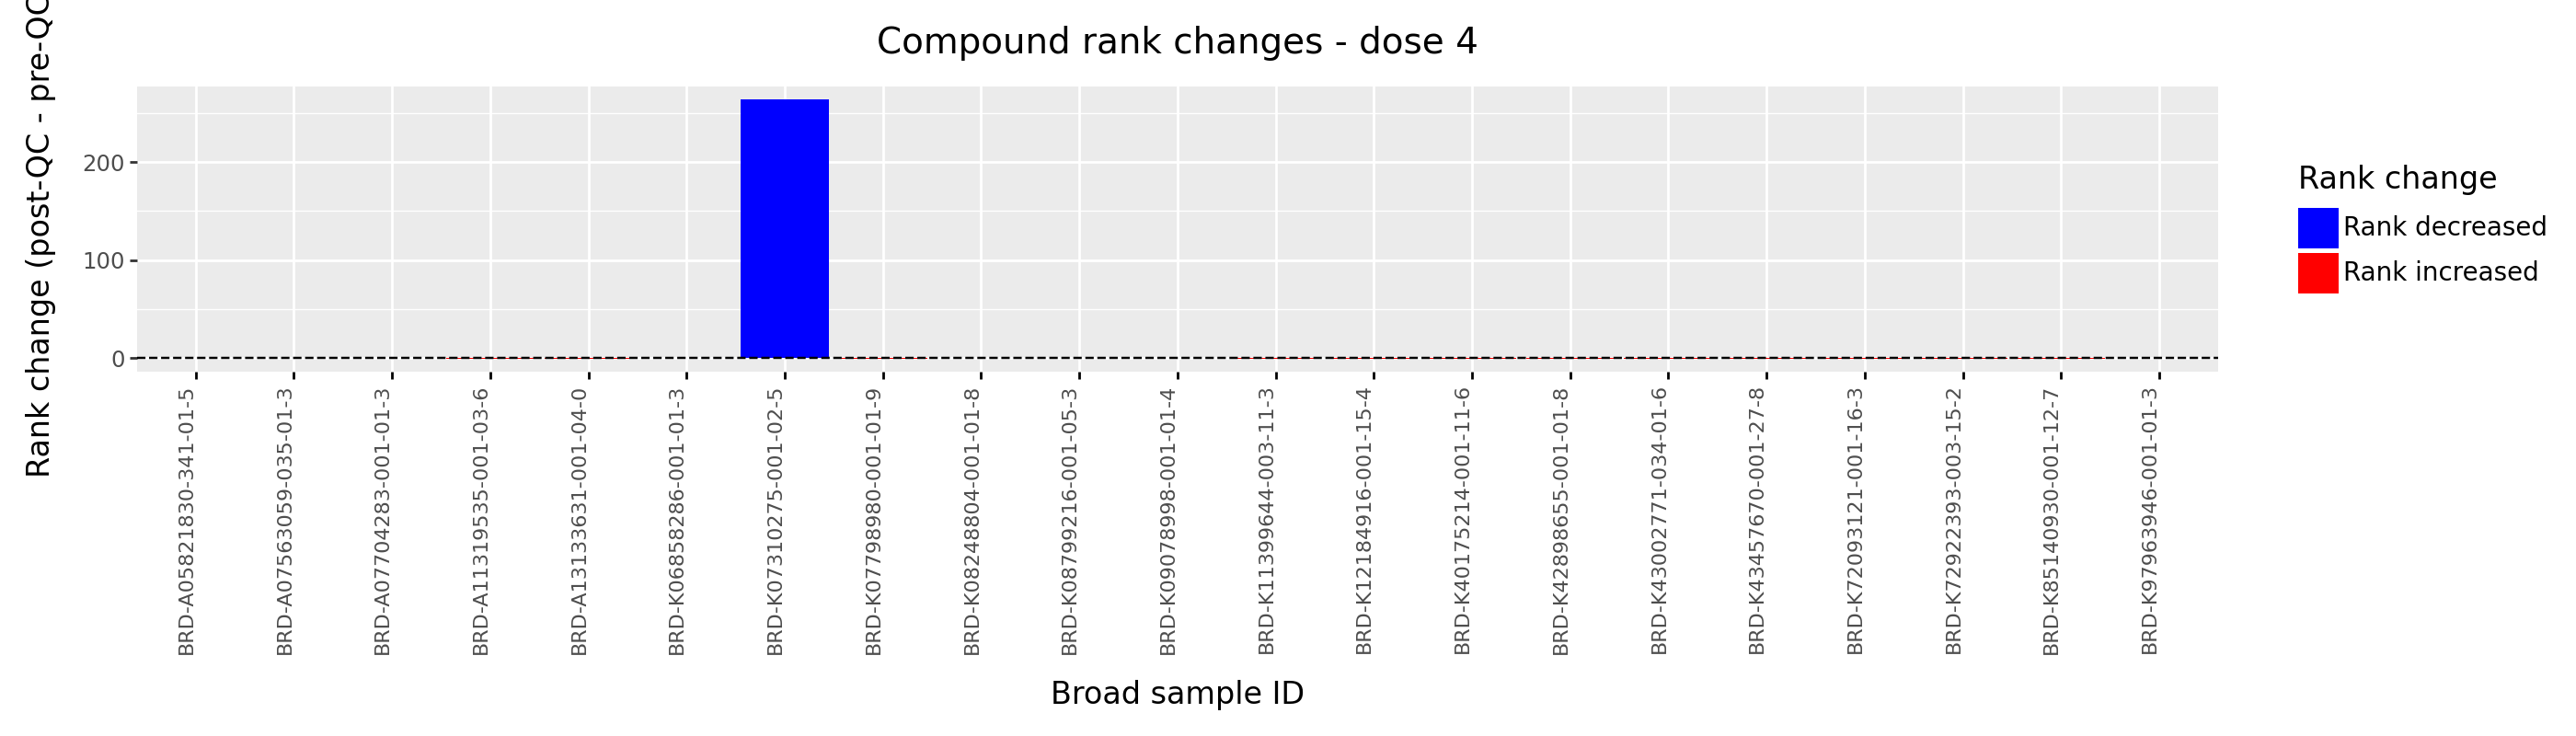

In [16]:
# Step 1: Identify top 20 per dose
top20_pre = merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.nsmallest(20, "preQC_rank")
)[["Metadata_broad_sample", "Metadata_dose_recode", "preQC_rank"]]

top20_post = merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.nsmallest(20, "postQC_rank")
)[["Metadata_broad_sample", "Metadata_dose_recode", "postQC_rank"]]

# Step 2: Union of compounds
rank_change = pd.merge(
    top20_pre,
    top20_post,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="outer",
)

# Step 3: Fill missing ranks from full dataset
rank_change = pd.merge(
    rank_change,
    merged_map_sorted[
        ["Metadata_broad_sample", "Metadata_dose_recode", "preQC_rank", "postQC_rank"]
    ],
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
    suffixes=("_tmp", ""),
)

# Step 4: Compute rank differences
rank_change["rank_diff"] = rank_change["preQC_rank"] - rank_change["postQC_rank"]


# Step 5: Define color based on rank change
def get_color(r: pd.Series) -> str:
    """Get color for rank change visualization.

    Args:
        r (pd.Series): A row from the DataFrame containing rank information.

    Returns:
        str: The color associated with the rank change.
    """
    if pd.isna(r["preQC_rank"]):
        return "gray"  # new post-QC top 20
    elif r["rank_diff"] < 0:
        return "red"  # increased (rank number went down = not important)
    else:
        return "blue"  # decreased (rank number went up = improved)


rank_change["color"] = rank_change.apply(get_color, axis=1)

# Step 6: Order compounds per dose for plotting
rank_change["sort_rank"] = rank_change["preQC_rank"].fillna(1000)
rank_change = rank_change.sort_values(["Metadata_dose_recode", "sort_rank"])

# Step 7: Plot per dose using plotnine
for dose, df_dose in rank_change.groupby("Metadata_dose_recode"):
    # Skip doses with no rank changes (all zeros or NaNs)
    if df_dose["rank_diff"].fillna(0).eq(0).all():
        continue

    p = (
        ggplot(df_dose, aes(x="Metadata_broad_sample", y="rank_diff", fill="color"))
        + geom_bar(stat="identity")
        + geom_hline(yintercept=0, color="black", linetype="dashed")
        + scale_fill_manual(
            name="Rank change",
            values={"red": "red", "blue": "blue"},
            labels=["Rank decreased", "Rank increased"],
        )
        + theme(
            title=element_text(size=14),
            axis_text_x=element_text(rotation=90, hjust=1, size=8),
            axis_title_x=element_text(size=12),
            axis_title_y=element_text(size=12),
            legend_title=element_text(size=12),
            legend_text=element_text(size=10),
        )
        + labs(
            title=f"Compound rank changes - dose {dose}",
            x="Broad sample ID",
            y="Rank change (post-QC - pre-QC)",
            color="Avg prop failed cells",
        )
    )
    # Save plot as PNG
    plot_path = f"figures/rank_change_dose_{dose}_bar_plot.png"
    p.save(plot_path, width=14, height=6, dpi=600)
    p.show()

In [ ]:
# Filter for compounds where rank_diff > 0 (rank improved) for dose 1 and 2
improved_dose1 = rank_change[
    (rank_change["Metadata_dose_recode"] == 1) & (rank_change["rank_diff"] > 0)
]
improved_dose2 = rank_change[
    (rank_change["Metadata_dose_recode"] == 2) & (rank_change["rank_diff"] > 0)  # noqa: PLR2004
]

# Concatenate and get unique broad samples (should be 9 in total)
# Only include broad sample as column
improved_compounds = pd.concat([improved_dose1, improved_dose2])[
    ["Metadata_broad_sample", "Metadata_dose_recode"]
]
broad_samples = improved_compounds["Metadata_broad_sample"].unique()

print("Broad samples of the 9 compounds that went up in ranks from dose 1 and 2:")
for sample in broad_samples:
    print(sample)

Broad samples of the 9 compounds that went up in ranks from dose 1 and 2:
BRD-K92241597-001-06-0
BRD-K64538373-001-01-4
BRD-A15297126-001-04-3
BRD-K03194791-001-04-8
BRD-A13133631-001-04-0
BRD-K17743125-001-08-4
BRD-K12787259-001-04-3


In [ ]:
# For each of the 9 compounds at their respective dose, get the pre-QC rank
preqc_ranks = []
for _, row in improved_compounds.iterrows():
    sample = row["Metadata_broad_sample"]
    dose = row["Metadata_dose_recode"]
    # Find the preQC_rank for this sample and dose
    rank = merged_map_sorted.loc[
        (merged_map_sorted["Metadata_broad_sample"] == sample)
        & (merged_map_sorted["Metadata_dose_recode"] == dose),
        "preQC_rank",
    ]
    if not rank.empty:
        preqc_ranks.append(rank.values[0])

# Compute the average pre-QC rank
avg_preqc_rank = np.mean(preqc_ranks)
print(
    "Average pre-QC mAP rank for the 9 compounds at their respective doses: "
    f"{avg_preqc_rank:.2f}"
)

Average pre-QC mAP rank for the 9 compounds at their respective doses: 129.00


In [ ]:
# Calculate total passed and failed cells per sample and dose
cell_counts = (
    post_qc_df_activity.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])
    .agg(
        total_passed=("Metadata_sc_count_passed_qc", "sum"),
        total_failed=("Metadata_sc_count_failed_qc", "sum"),
    )
    .reset_index()
)

# Calculate total and proportion failed
cell_counts["total_cells"] = cell_counts["total_passed"] + cell_counts["total_failed"]
cell_counts["proportion_failed"] = (
    cell_counts["total_failed"] / cell_counts["total_cells"]
)

# Merge with improved_compounds
improved_compounds = improved_compounds.merge(
    cell_counts, on=["Metadata_broad_sample", "Metadata_dose_recode"], how="left"
)

# Add back Metadata_moa from post_qc_df_activity
moa_info = post_qc_df_activity[
    ["Metadata_broad_sample", "Metadata_moa"]
].drop_duplicates()
improved_compounds = improved_compounds.merge(
    moa_info, on="Metadata_broad_sample", how="left"
)

# Compute the average proportion failed across each compound in this list
avg_proportion_failed = improved_compounds["proportion_failed"].mean()
print(
    f"Average proportion of failed cells across the 9 compounds: "
    f"{avg_proportion_failed:.4f}"
)

# Compute the average of the total passed across each compound in this list
avg_total_passed = improved_compounds["total_passed"].mean()
print(f"Average total passed cells across the 9 compounds: {avg_total_passed:.0f}")

# Quantify the number of duplicate compounds (same broad sample at different doses)
duplicate_counts = improved_compounds["Metadata_broad_sample"].value_counts()
num_duplicates = (duplicate_counts > 1).sum()
print(
    "Number of duplicate compounds (same broad sample at different doses): "
    f"{num_duplicates}"
)

print(improved_compounds.shape)
improved_compounds.head(10)

Average proportion of failed cells across the 9 compounds: 0.2583
Average total passed cells across the 9 compounds: 6152
Number of duplicate compounds (same broad sample at different doses): 2
(9, 7)


,Metadata_broad_sample,Metadata_dose_recode,total_passed,total_failed,total_cells,proportion_failed,Metadata_moa
0,BRD-K92241597-001-06-0,1,8282,3979.0,12261.0,0.324525,peptidase inhibitor
1,BRD-K64538373-001-01-4,1,8399,3793.0,12192.0,0.311106,MEK inhibitor
2,BRD-A15297126-001-04-3,1,4074,1338.0,5412.0,0.247228,glucocorticoid receptor agonist
3,BRD-K03194791-001-04-8,1,5002,503.0,5505.0,0.091371,phosphodiesterase inhibitor
4,BRD-A13133631-001-04-0,2,6316,2896.0,9212.0,0.314373,glucocorticoid receptor agonist
5,BRD-A15297126-001-04-3,2,4358,1545.0,5903.0,0.261731,glucocorticoid receptor agonist
6,BRD-K17743125-001-08-4,2,8855,3625.0,12480.0,0.290465,HDAC inhibitor
7,BRD-K03194791-001-04-8,2,6185,774.0,6959.0,0.111223,phosphodiesterase inhibitor
8,BRD-K12787259-001-04-3,2,3897,2312.0,6209.0,0.372363,RNA polymerase inhibitor
